In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- File paths ---
jwst_csv = "fit_results_jwst.csv"
jwst_hst_csv = "fit_results_jwst_hst.csv"
dat_path = "../phot_joined_avmass.dat"

# --- Load results ---
df_jwst = pd.read_csv(jwst_csv)
df_hst = pd.read_csv(jwst_hst_csv)

# --- Load true AV/mass from the data file ---
true_av, true_mass = [], []
with open(dat_path, 'r') as f:
    for line in f:
        if line.startswith('#') or not line.strip():
            continue
        parts = [float(x) for x in line.split()]
        true_av.append(parts[14])
        true_mass.append(parts[15])

# --- Attach ground truth to both dataframes ---
df_jwst['true_AV'] = [true_av[i] if i < len(true_av) else np.nan for i in df_jwst['index']]
df_jwst['true_mass'] = [true_mass[i] if i < len(true_mass) else np.nan for i in df_jwst['index']]
df_hst['true_AV'] = [true_av[i] if i < len(true_av) else np.nan for i in df_hst['index']]
df_hst['true_mass'] = [true_mass[i] if i < len(true_mass) else np.nan for i in df_hst['index']]

# --- Keep only rows present in both results, aligned by index ---
df = pd.merge(df_jwst, df_hst, on='index', suffixes=('_jwst','_hst'))

print(f"JWST-only results: {len(df_jwst)} rows")
print(f"JWST+HST results:  {len(df_hst)} rows")
print(f"Common matched rows after merge: {len(df)}")

# --- Attach ground truth once (from index alignment) ---
df['true_AV']   = [true_av[i] if i < len(true_av) else np.nan for i in df['index']]
df['true_mass'] = [true_mass[i] if i < len(true_mass) else np.nan for i in df['index']]

# --- Exclude bad values (apply to merged df) ---
df = df[(df['true_mass'] > 0) & (df['true_AV'] > 0)].copy()

print(f"Usable rows after filtering: {len(df)}")

JWST-only results: 989 rows
JWST+HST results:  752 rows
Common matched rows after merge: 752
Usable rows after filtering: 752


In [7]:
# --- Compute absolute and percent errors ---
for df in [df_jwst, df_hst]:
    df['mass_error'] = df['best_mass'] - df['true_mass']
    df['AV_error']   = df['best_AV'] - df['true_AV']
    df['mass_pct_error'] = np.where(df['true_mass'] != 0, 100 * df['mass_error'] / df['true_mass'], np.nan)
    df['AV_pct_error']   = np.where(df['true_AV'] != 0, 100 * df['AV_error'] / df['true_AV'], np.nan)

# --- Compute mean / median error summaries ---
summary = pd.DataFrame({
    'Run': ['JWST only', 'JWST + HST'],
    'Mean |Mass %Err|': [df_jwst['mass_pct_error'].abs().mean(), df_hst['mass_pct_error'].abs().mean()],
    'Median |Mass %Err|': [df_jwst['mass_pct_error'].abs().median(), df_hst['mass_pct_error'].abs().median()],
    'Mean |AV %Err|': [df_jwst['AV_pct_error'].abs().mean(), df_hst['AV_pct_error'].abs().mean()],
    'Median |AV %Err|': [df_jwst['AV_pct_error'].abs().median(), df_hst['AV_pct_error'].abs().median()],
})
print(summary)

          Run  Mean |Mass %Err|  Median |Mass %Err|  Mean |AV %Err|  \
0   JWST only         14.149930            8.872453       23.352154   
1  JWST + HST         20.681598           11.936485       24.067529   

   Median |AV %Err|  
0         13.480983  
1         18.321825  


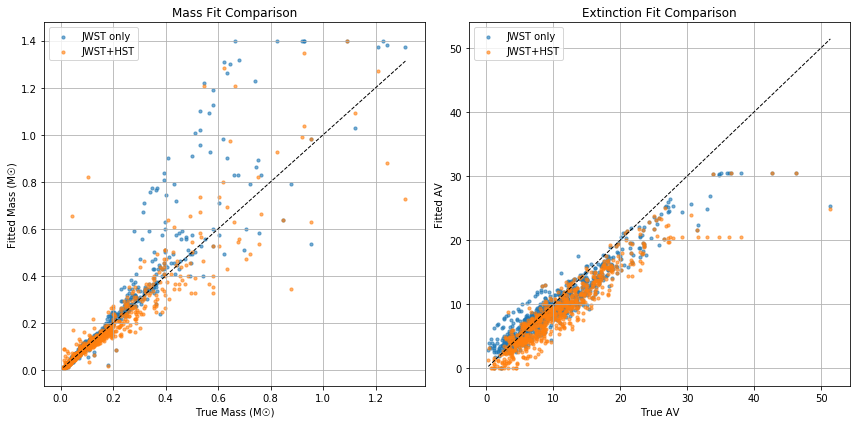

In [8]:
# --- Identity plots for mass and AV ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Mass comparison
axes[0].scatter(df_jwst['true_mass'], df_jwst['best_mass'], s=10, alpha=0.6, label='JWST only', color='tab:blue')
axes[0].scatter(df_hst['true_mass'], df_hst['best_mass'], s=10, alpha=0.6, label='JWST+HST', color='tab:orange')
axes[0].plot([min(df_jwst['true_mass'].min(), df_hst['true_mass'].min()),
              max(df_jwst['true_mass'].max(), df_hst['true_mass'].max())],
             [min(df_jwst['true_mass'].min(), df_hst['true_mass'].min()),
              max(df_jwst['true_mass'].max(), df_hst['true_mass'].max())],
             'k--', lw=1)
axes[0].set_xlabel("True Mass (M☉)")
axes[0].set_ylabel("Fitted Mass (M☉)")
axes[0].set_title("Mass Fit Comparison")
axes[0].legend()
axes[0].grid(True)

# AV comparison
axes[1].scatter(df_jwst['true_AV'], df_jwst['best_AV'], s=10, alpha=0.6, label='JWST only', color='tab:blue')
axes[1].scatter(df_hst['true_AV'], df_hst['best_AV'], s=10, alpha=0.6, label='JWST+HST', color='tab:orange')
axes[1].plot([min(df_jwst['true_AV'].min(), df_hst['true_AV'].min()),
              max(df_jwst['true_AV'].max(), df_hst['true_AV'].max())],
             [min(df_jwst['true_AV'].min(), df_hst['true_AV'].min()),
              max(df_jwst['true_AV'].max(), df_hst['true_AV'].max())],
             'k--', lw=1)
axes[1].set_xlabel("True AV")
axes[1].set_ylabel("Fitted AV")
axes[1].set_title("Extinction Fit Comparison")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

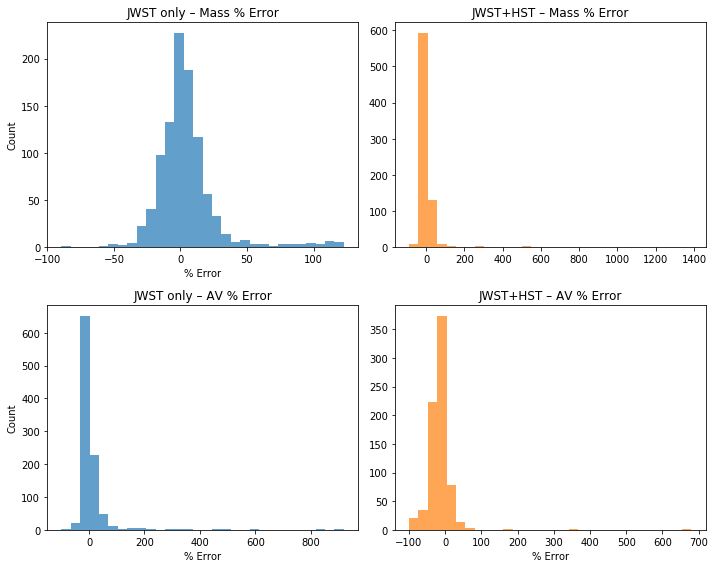

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0,0].hist(df_jwst['mass_pct_error'].dropna(), bins=30, color='tab:blue', alpha=0.7)
axes[0,0].set_title("JWST only – Mass % Error")
axes[0,0].set_xlabel("% Error"); axes[0,0].set_ylabel("Count")

axes[0,1].hist(df_hst['mass_pct_error'].dropna(), bins=30, color='tab:orange', alpha=0.7)
axes[0,1].set_title("JWST+HST – Mass % Error")

axes[1,0].hist(df_jwst['AV_pct_error'].dropna(), bins=30, color='tab:blue', alpha=0.7)
axes[1,0].set_title("JWST only – AV % Error")
axes[1,0].set_xlabel("% Error"); axes[1,0].set_ylabel("Count")

axes[1,1].hist(df_hst['AV_pct_error'].dropna(), bins=30, color='tab:orange', alpha=0.7)
axes[1,1].set_title("JWST+HST – AV % Error")
axes[1,1].set_xlabel("% Error")

plt.tight_layout()
plt.show()